# AMAZON CUSTOMER DATASET ANALISYS

## Overview

This dataset is a synthetically generated but highly realistic simulation of an Amazon-like e-commerce platform. It contains 1,000,000 transaction records with 20 carefully engineered features designed to mimic real-world customer behavior, product dynamics, and marketplace interactions.

The dataset is ideal for machine learning, data analysis, recommendation systems, and business intelligence tasks.

## Motivation
Real-world e-commerce datasets are often restricted due to privacy and business sensitivity. This dataset bridges that gap by providing:
- Realistic correlations between variables
- Behavior-driven patterns (returns, ratings, delivery delays)
- Category-specific pricing and discount strategies
- Marketplace-level complexity

## Dataset Characteristics
- Rows: 1,000,000
- Columns: 20
- Data Type: Tabular
- Format: CSV
- Domain: E-commerce / Retail

## Features Description
| Column Name | Description |
| :--- | :--- |
| user_id | Unique identifier for each user |
| product_id | Unique identifier for each product |
| category | Main product category (Electronics, Clothing, etc.) |
| subcategory | More specific classification within category |
| brand | Product brand name |
| price | Original product price |
| discount | Discount percentage applied |
| final_price | Price after discount |
| rating | Product rating (1–5 scale) |
| review_count | Number of reviews (log-normal distribution) |
| stock | Available inventory units |
| seller_id | Unique seller identifier |
| seller_rating | Seller rating (2.5–5.0) |
| purchase_date | Date of transaction (last 2 years) |
| shipping_time_days | Delivery time in days |
| location | Customer city |
| device | Platform used (Mobile, Web, Tablet) |
| payment_method | Payment type (UPI, Card, COD) |
| is_returned | Whether the product was returned |
| delivery_status | Final delivery outcome |

## License
https://www.mit.edu/~amini/LICENSE.md


## Kaggle
https://www.kaggle.com/datasets/sharmajicoder/amazon-e-commerce


## IMPORT LIBRARY

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
import joblib

# LOAD DATASET

In [43]:

df = pd.read_csv('amazon_ecommerce_1M.csv').sample(n=75000, random_state=42)
df.head()

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status
987231,U907645,P13100,Sports,Cycling,Nike,13307.41,24.89,9995.09,3.2,26,308,S4473,3.5,2025-08-28,4,Mumbai,Tablet,UPI,True,Returned
79954,U995373,P11820,Electronics,Headphones,Samsung,5464.82,15.70,4606.69,3.1,5,453,S1390,2.7,2025-10-05,4,Mumbai,Tablet,Cash on Delivery,False,Delayed
567130,U565186,P25469,Beauty,Makeup,Lenovo,3437.74,45.41,1876.51,3.7,41,222,S4525,3.5,2025-10-29,2,Hyderabad,Web,Debit Card,False,Delayed
500891,U338654,P96278,Home,Kitchen,H&M,7754.11,14.21,6652.29,4.1,128,479,S8223,2.9,2024-05-08,4,Hyderabad,Tablet,UPI,False,In Transit
55399,U351028,P20410,Clothing,Men,Apple,967.17,30.44,672.76,3.9,18,471,S3841,3.3,2025-04-06,5,Delhi,Mobile App,Credit Card,False,Delayed


# Exploratory Data Analyst

In [44]:
# number of rows and cols 
print(df.shape)

# feature
print(df.columns)

(75000, 20)
Index(['user_id', 'product_id', 'category', 'subcategory', 'brand', 'price',
       'discount', 'final_price', 'rating', 'review_count', 'stock',
       'seller_id', 'seller_rating', 'purchase_date', 'shipping_time_days',
       'location', 'device', 'payment_method', 'is_returned',
       'delivery_status'],
      dtype='str')


In [45]:
# data types each column
df.info()

<class 'pandas.DataFrame'>
Index: 75000 entries, 987231 to 102307
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             75000 non-null  str    
 1   product_id          75000 non-null  str    
 2   category            75000 non-null  str    
 3   subcategory         75000 non-null  str    
 4   brand               75000 non-null  str    
 5   price               75000 non-null  float64
 6   discount            75000 non-null  float64
 7   final_price         75000 non-null  float64
 8   rating              75000 non-null  float64
 9   review_count        75000 non-null  int64  
 10  stock               75000 non-null  int64  
 11  seller_id           75000 non-null  str    
 12  seller_rating       75000 non-null  float64
 13  purchase_date       75000 non-null  str    
 14  shipping_time_days  75000 non-null  int64  
 15  location            75000 non-null  str    
 16  device        

In [46]:
# statistics description
df.describe(include='all')

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status
count,75000,75000,75000,75000,75000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000,75000.000000,75000,75000.000000,75000,75000,75000,75000,75000
unique,71897,50733,5,16,12,NaN,NaN,NaN,NaN,NaN,NaN,8994,NaN,731,NaN,5,3,4,2,4
top,U772501,P30488,Beauty,Skincare,Zara,NaN,NaN,NaN,NaN,NaN,NaN,S5732,NaN,2024-06-06,NaN,Mumbai,Mobile App,Debit Card,False,Delayed
freq,4,7,15206,5134,6431,NaN,NaN,NaN,NaN,NaN,NaN,22,NaN,136,NaN,15119,25246,18872,66251,22142
mean,NaN,NaN,NaN,NaN,NaN,13110.052305,28.972158,9851.129135,3.924888,32.525960,249.725773,NaN,3.743317,NaN,3.169160,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,17960.763190,14.669688,14162.334369,0.520261,42.695501,144.804264,NaN,0.721639,NaN,1.670144,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,200.140000,5.000000,106.090000,1.700000,0.000000,0.000000,NaN,2.500000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,2674.275000,16.900000,1687.967500,3.600000,10.000000,125.000000,NaN,3.100000,NaN,2.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,4937.490000,28.040000,3747.975000,3.900000,19.000000,249.000000,NaN,3.700000,NaN,3.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,14069.412500,39.210000,10321.220000,4.300000,39.000000,376.000000,NaN,4.400000,NaN,5.000000,NaN,NaN,NaN,NaN,NaN


In [47]:
# duplicate values
df.duplicated().sum()

np.int64(0)

In [48]:
# missing values
df.isnull().sum()

user_id               0
product_id            0
category              0
subcategory           0
brand                 0
price                 0
discount              0
final_price           0
rating                0
review_count          0
stock                 0
seller_id             0
seller_rating         0
purchase_date         0
shipping_time_days    0
location              0
device                0
payment_method        0
is_returned           0
delivery_status       0
dtype: int64

## DATA DISTRIBUTION

In [49]:
# standard deviation 
numerical_cols = df.select_dtypes(include='number')

std_df = pd.DataFrame([
    {
        'Column': column,
        'Standard Deviation': df[column].std()
    }
    for column in numerical_cols.columns
])

std_df.sort_values(by='Standard Deviation', ascending=False)

,Column,Standard Deviation
0,price,17960.763190
2,final_price,14162.334369
5,stock,144.804264
4,review_count,42.695501
1,discount,14.669688
7,shipping_time_days,1.670144
6,seller_rating,0.721639
3,rating,0.520261


In [50]:
# variance
vari_df = pd.DataFrame([
    {
        'Column': column, 
        'Variance': df[column].var()
    }
    for column in numerical_cols
])

vari_df.sort_values(by='Variance', ascending=False)

,Column,Variance
0,price,3.225890e+08
2,final_price,2.005717e+08
5,stock,2.096827e+04
4,review_count,1.822906e+03
1,discount,2.151998e+02
7,shipping_time_days,2.789382e+00
6,seller_rating,5.207631e-01
3,rating,2.706711e-01


In [51]:
# data skewness
skewness_df = pd.DataFrame([
    {
        'Column': column, 
        'Skewness': df[column].skew()
    }
    for column in numerical_cols
])

skewness_df.sort_values(by='Skewness', ascending=False)

,Column,Skewness
4,review_count,5.234042
2,final_price,2.243733
0,price,2.142967
1,discount,0.430040
7,shipping_time_days,0.158623
6,seller_rating,0.010700
5,stock,0.003989
3,rating,-0.073554


## Exploratory Data Analyst (EDA)

In [52]:
# split column

numerical_cols = df.select_dtypes(include=['number']).columns
categorial_cols = df.select_dtypes(include=['str']).columns

print('Numerical Columns: ', numerical_cols)
print('Categorial Columns: ', categorial_cols)

Numerical Columns:  Index(['price', 'discount', 'final_price', 'rating', 'review_count', 'stock',
       'seller_rating', 'shipping_time_days'],
      dtype='str')
Categorial Columns:  Index(['user_id', 'product_id', 'category', 'subcategory', 'brand',
       'seller_id', 'purchase_date', 'location', 'device', 'payment_method',
       'delivery_status'],
      dtype='str')


In [53]:
# outlier detection using Inter Quartile Range (IQR)
q1 = df[numerical_cols].quantile(0.25)
q3 = df[numerical_cols].quantile(0.75)
iqr = q3-q1

# boundaries
upper_bound = q1 - 1.5 * iqr
lower_bound = q3 + 1.5 * iqr

# filtered dataframe
df_outliers = df[
    ((df[numerical_cols] < lower_bound) | 
     (df[numerical_cols] > upper_bound)).any(axis=1)
]

df_outliers

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status
987231,U907645,P13100,Sports,Cycling,Nike,13307.41,24.89,9995.09,3.2,26,308,S4473,3.5,2025-08-28,4,Mumbai,Tablet,UPI,True,Returned
79954,U995373,P11820,Electronics,Headphones,Samsung,5464.82,15.70,4606.69,3.1,5,453,S1390,2.7,2025-10-05,4,Mumbai,Tablet,Cash on Delivery,False,Delayed
567130,U565186,P25469,Beauty,Makeup,Lenovo,3437.74,45.41,1876.51,3.7,41,222,S4525,3.5,2025-10-29,2,Hyderabad,Web,Debit Card,False,Delayed
500891,U338654,P96278,Home,Kitchen,H&M,7754.11,14.21,6652.29,4.1,128,479,S8223,2.9,2024-05-08,4,Hyderabad,Tablet,UPI,False,In Transit
55399,U351028,P20410,Clothing,Men,Apple,967.17,30.44,672.76,3.9,18,471,S3841,3.3,2025-04-06,5,Delhi,Mobile App,Credit Card,False,Delayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739177,U311386,P92971,Beauty,Skincare,Lenovo,988.89,11.50,875.12,4.1,44,346,S2570,4.6,2025-01-02,4,Chennai,Mobile App,Cash on Delivery,False,In Transit
669410,U348571,P77274,Electronics,Camera,H&M,76114.20,37.07,47900.47,4.9,33,5,S8096,3.4,2025-07-24,6,Hyderabad,Tablet,Cash on Delivery,False,Delivered
325647,U480333,P35879,Electronics,Camera,Zara,42453.73,5.57,40088.39,4.8,17,328,S2144,4.4,2024-11-22,4,Delhi,Tablet,Debit Card,False,Delivered
93812,U112990,P72619,Home,Kitchen,H&M,12084.78,43.20,6864.17,4.1,17,497,S4375,3.6,2026-02-16,2,Hyderabad,Web,UPI,False,Delayed


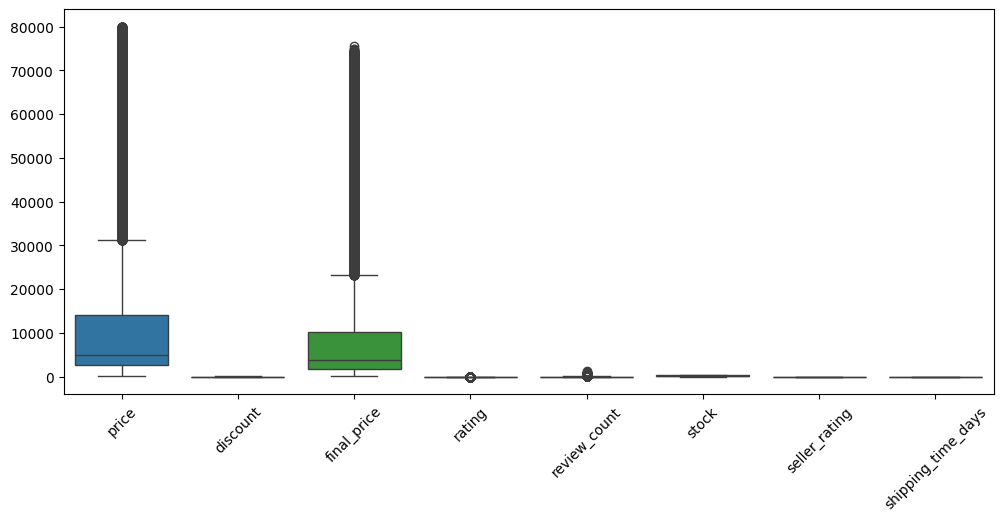

In [54]:
# outliers using boxplot
plt.figure(figsize=(12, 5))
sns.boxplot(df[numerical_cols])
plt.xticks(rotation=45)
plt.show()

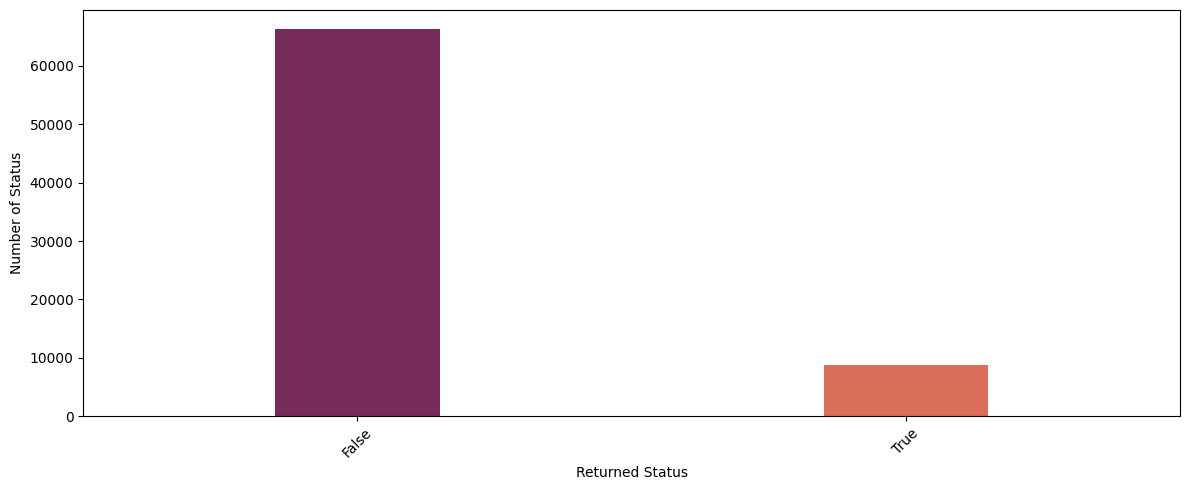

In [55]:
# boolean target label balancing data
# target label dsitribution
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x=df['is_returned'], palette='rocket', hue=df['is_returned'], legend=False, width=0.3)
plt.xlabel('Returned Status')
plt.ylabel('Number of Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

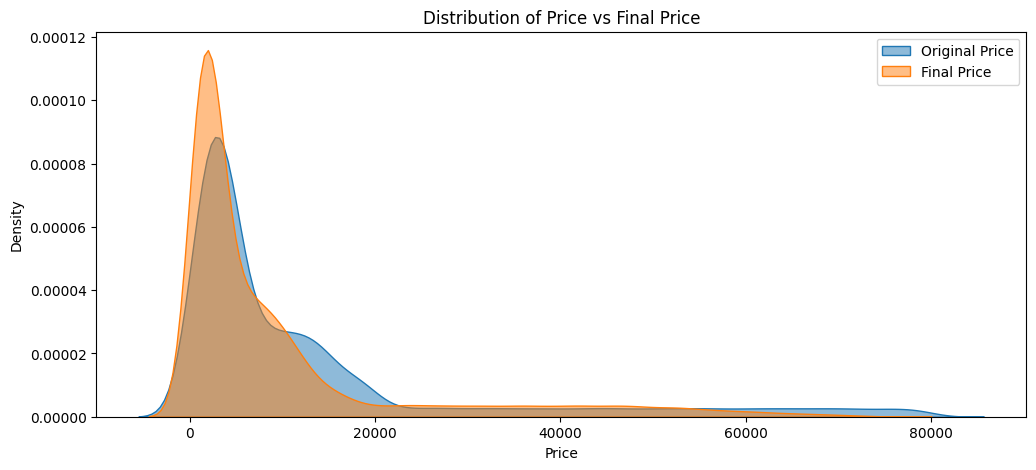

In [56]:
# 1. Price distribution before and after discount

plt.figure(figsize=(12, 5))
sns.kdeplot(data=df, x='price', label='Original Price', fill=True, alpha=0.5)
sns.kdeplot(data=df, x='final_price', label='Final Price', fill=True, alpha=0.5)
plt.title('Distribution of Price vs Final Price')
plt.xlabel('Price')
plt.ylabel('Density')
plt.legend()
plt.show()

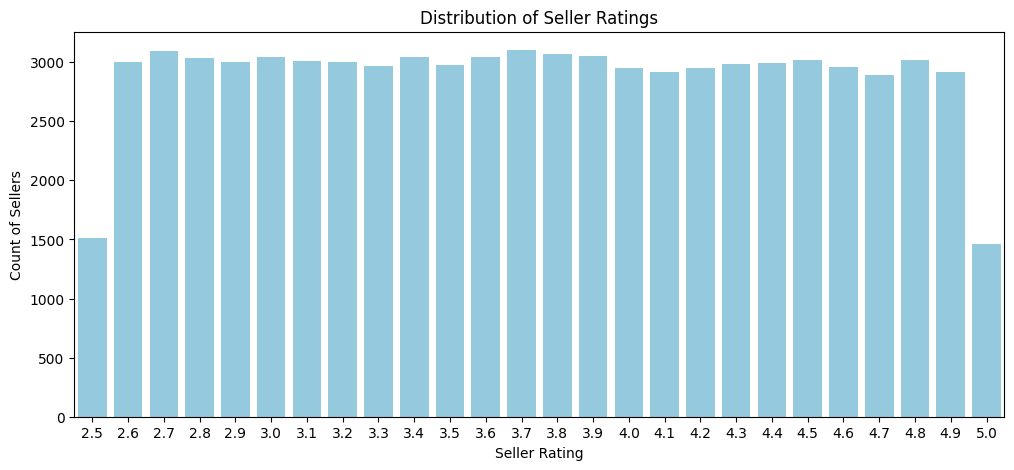

In [57]:
# 2. Seller Peformance Based on Rating

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='seller_rating', color='skyblue')
plt.title('Distribution of Seller Ratings')
plt.xlabel('Seller Rating')
plt.ylabel('Count of Sellers')
plt.show()

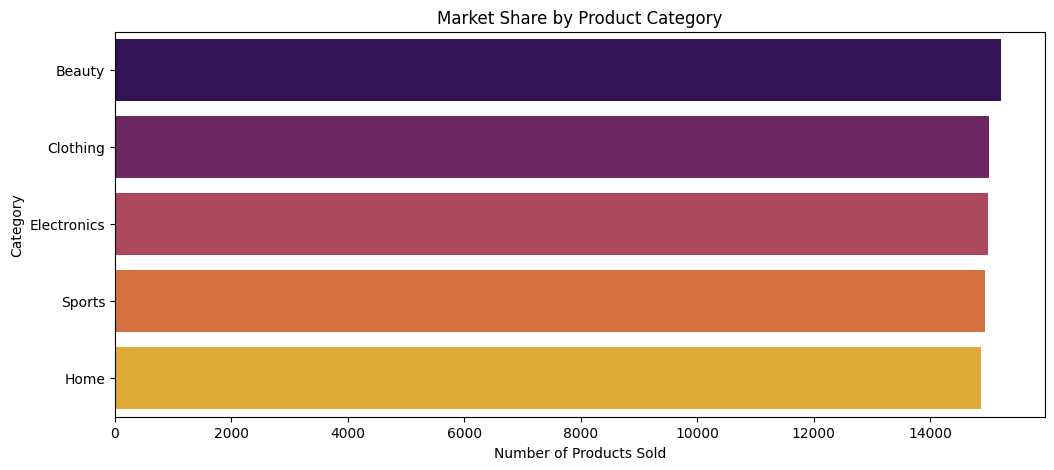

In [58]:
# 3. Biggest Marker Share by Product Category  

plt.figure(figsize=(12, 5))
category_counts = df['category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, palette='inferno', hue=category_counts.index, dodge=False)
plt.title('Market Share by Product Category')
plt.xlabel('Number of Products Sold')
plt.ylabel('Category')
plt.show()

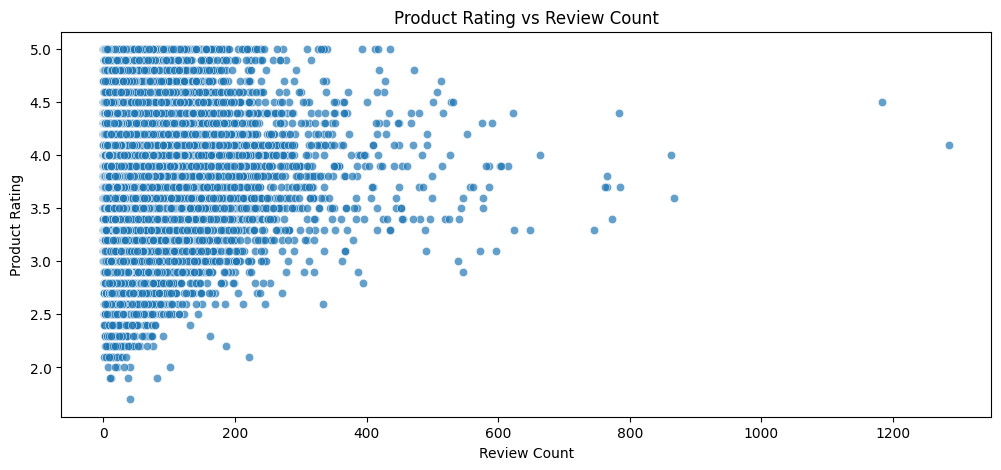

In [59]:
# 4. Correlation Between Number of Reviews and Product Rating

plt.figure(figsize=(12, 5))
sns.scatterplot(data=df, x='review_count', y='rating', alpha=0.7)
plt.title('Product Rating vs Review Count')
plt.xlabel('Review Count')
plt.ylabel('Product Rating')
plt.show()

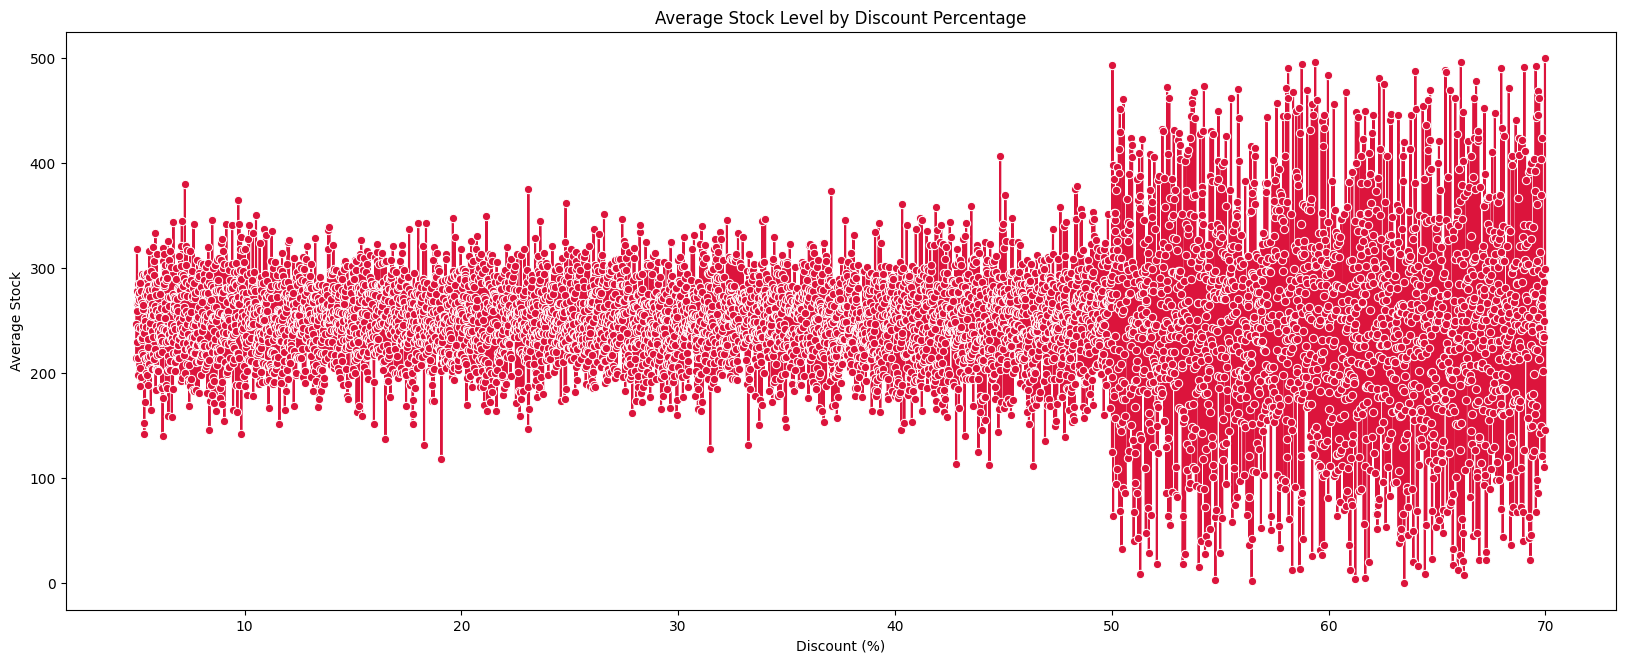

In [60]:
# 5. Correlation Between Discount and Product Stock Left

plt.figure(figsize=(20, 7.5))
avg_stock_by_discount = df.groupby('discount')['stock'].mean().reset_index()
sns.lineplot(data=avg_stock_by_discount, x='discount', y='stock', color='crimson', marker='o')
plt.title('Average Stock Level by Discount Percentage')
plt.xlabel('Discount (%)')
plt.ylabel('Average Stock')
plt.show()

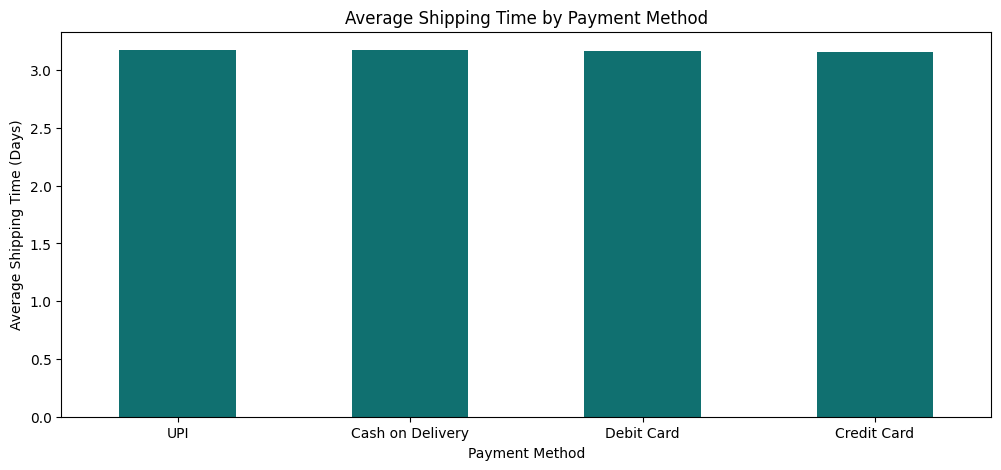

In [61]:
# 6. Efect of Pyament Method to Shipping Time

plt.figure(figsize=(12, 5))
sns.barplot(data=df, x='payment_method', y='shipping_time_days', estimator='mean', errorbar=None, color='teal', width=0.5)
plt.title('Average Shipping Time by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Shipping Time (Days)')
plt.show()

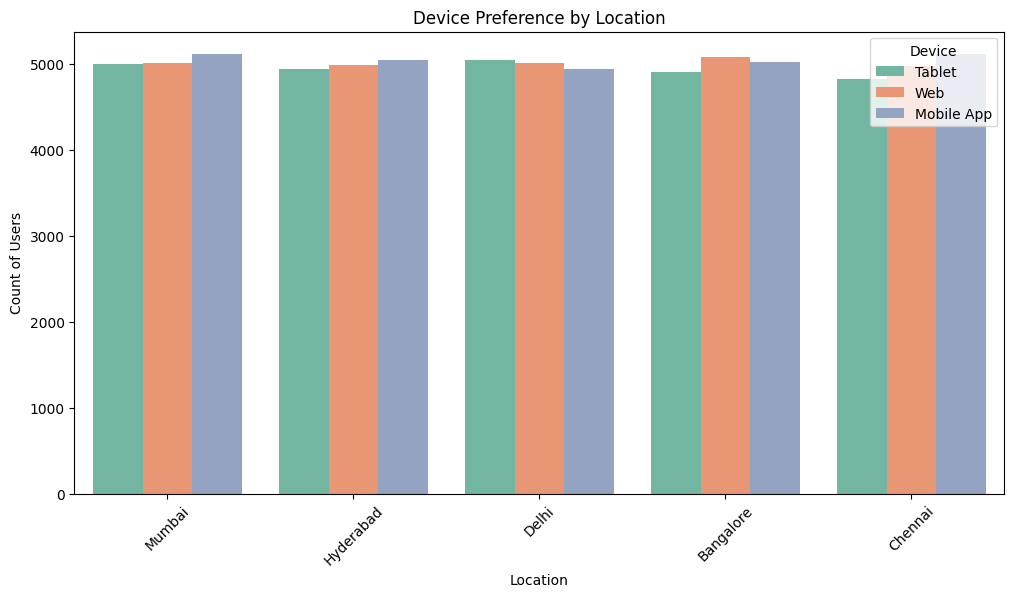

In [62]:
# 7. Shopping Device Preferences by Location

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='location', hue='device', palette='Set2')
plt.title('Device Preference by Location')
plt.xlabel('Location')
plt.ylabel('Count of Users')
plt.xticks(rotation=45)
plt.legend(title='Device')
plt.show()

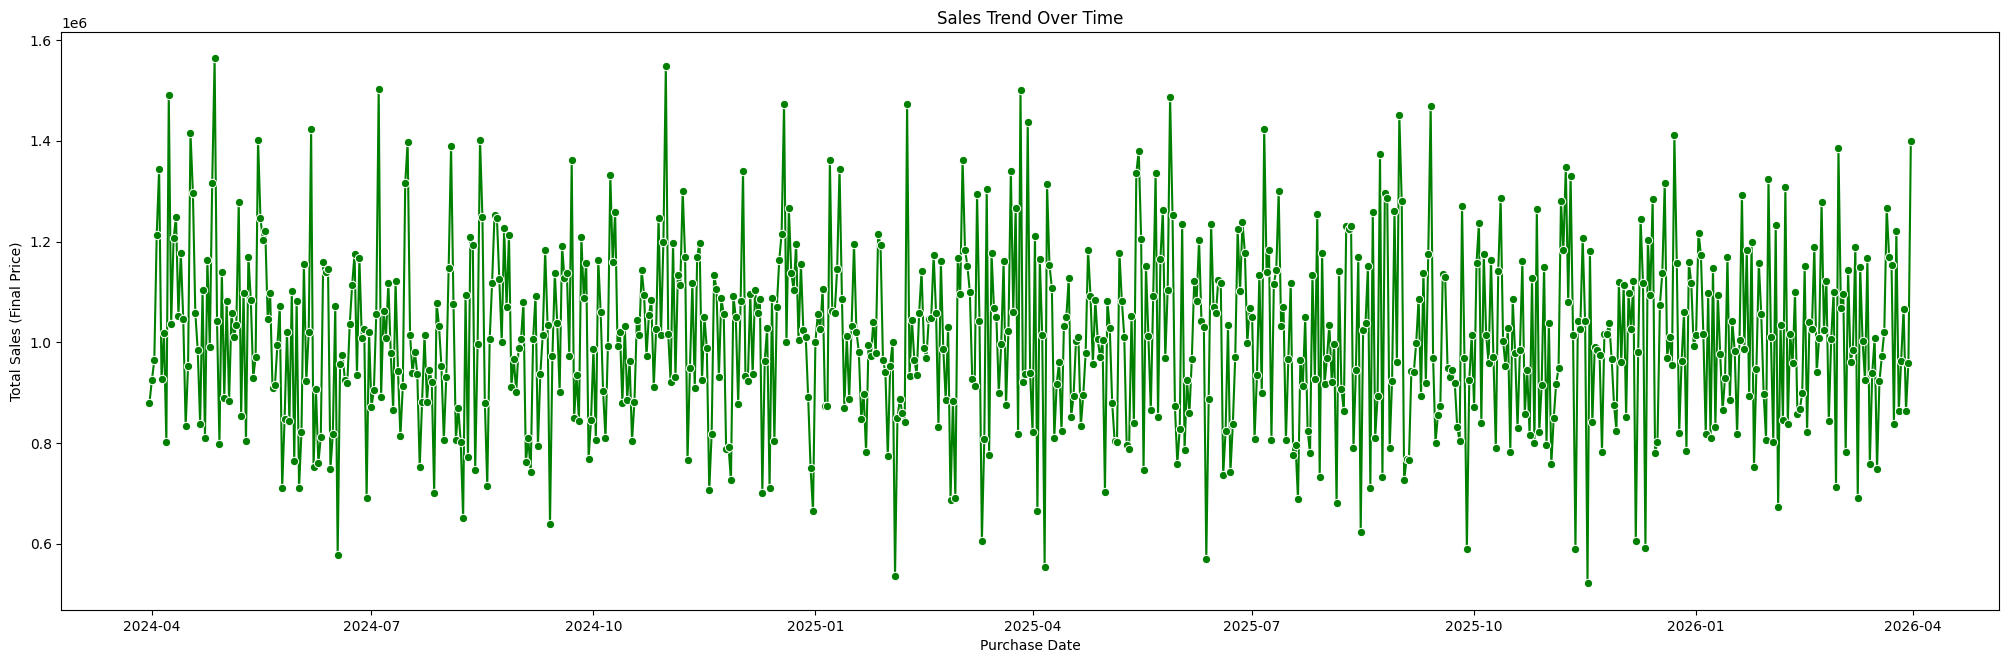

In [63]:
# 8. Transaction Trend Based On Time Purcahsing

df['purchase_date'] = pd.to_datetime(df['purchase_date'])
daily_sales = df.groupby('purchase_date')['final_price'].sum().reset_index()

plt.figure(figsize=(25, 7.5))
sns.lineplot(data=daily_sales, x='purchase_date', y='final_price', marker='o', color='green')
plt.title('Sales Trend Over Time')
plt.xlabel('Purchase Date')
plt.ylabel('Total Sales (Final Price)')
plt.show()

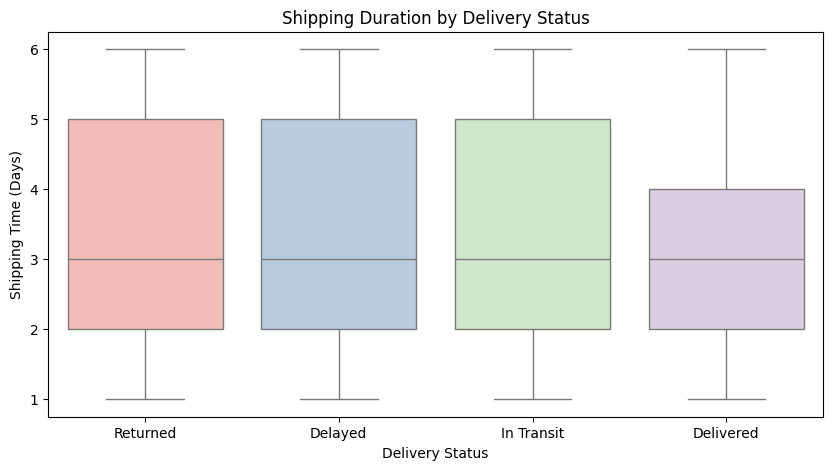

In [64]:
# 9. Accuracy of Shipping Time

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='delivery_status', y='shipping_time_days', palette='Pastel1', hue='delivery_status', dodge=False)
plt.title('Shipping Duration by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Shipping Time (Days)')
plt.show()

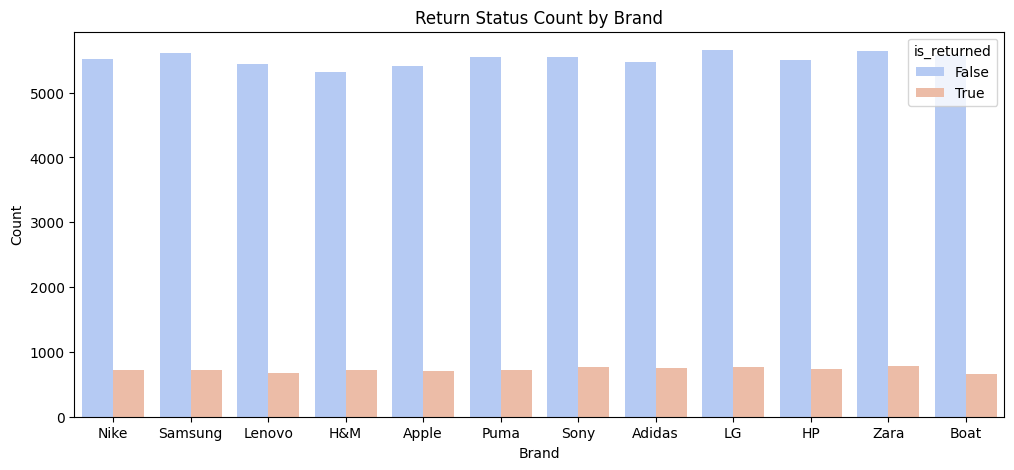

In [65]:
# 10. Brand Loyalty Based on roduct Rating

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='brand', hue='is_returned', palette='coolwarm')
plt.title('Return Status Count by Brand')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.show()

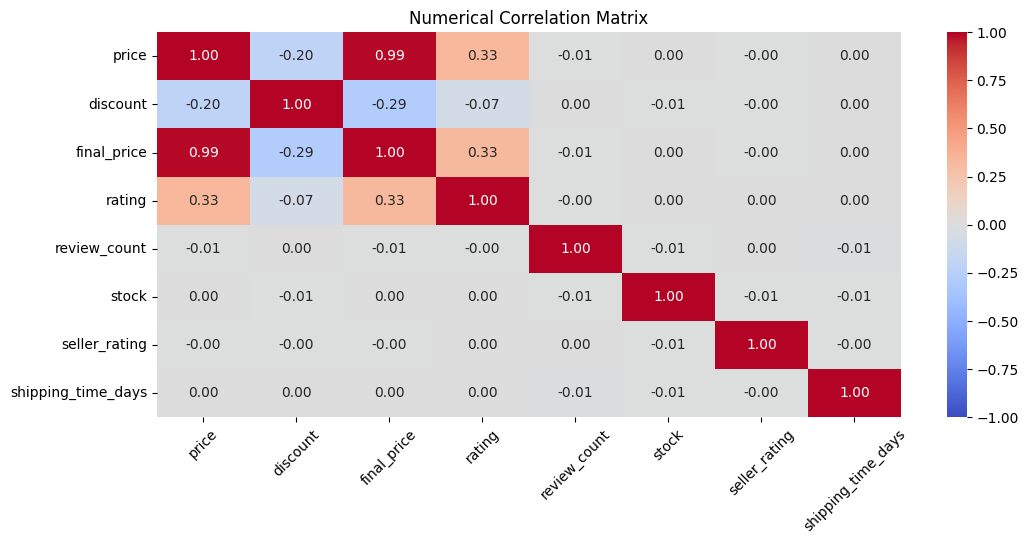

In [66]:
# numerical columns correlation
correlation = df[numerical_cols].corr()

# heatmap matriks
plt.figure(figsize=(12, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Numerical Correlation Matrix')
plt.xticks(rotation=45)
plt.show()

## PREPROCESSING

In [67]:
# drop irrelevant columns
df

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status
987231,U907645,P13100,Sports,Cycling,Nike,13307.41,24.89,9995.09,3.2,26,308,S4473,3.5,2025-08-28,4,Mumbai,Tablet,UPI,True,Returned
79954,U995373,P11820,Electronics,Headphones,Samsung,5464.82,15.70,4606.69,3.1,5,453,S1390,2.7,2025-10-05,4,Mumbai,Tablet,Cash on Delivery,False,Delayed
567130,U565186,P25469,Beauty,Makeup,Lenovo,3437.74,45.41,1876.51,3.7,41,222,S4525,3.5,2025-10-29,2,Hyderabad,Web,Debit Card,False,Delayed
500891,U338654,P96278,Home,Kitchen,H&M,7754.11,14.21,6652.29,4.1,128,479,S8223,2.9,2024-05-08,4,Hyderabad,Tablet,UPI,False,In Transit
55399,U351028,P20410,Clothing,Men,Apple,967.17,30.44,672.76,3.9,18,471,S3841,3.3,2025-04-06,5,Delhi,Mobile App,Credit Card,False,Delayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739177,U311386,P92971,Beauty,Skincare,Lenovo,988.89,11.50,875.12,4.1,44,346,S2570,4.6,2025-01-02,4,Chennai,Mobile App,Cash on Delivery,False,In Transit
669410,U348571,P77274,Electronics,Camera,H&M,76114.20,37.07,47900.47,4.9,33,5,S8096,3.4,2025-07-24,6,Hyderabad,Tablet,Cash on Delivery,False,Delivered
325647,U480333,P35879,Electronics,Camera,Zara,42453.73,5.57,40088.39,4.8,17,328,S2144,4.4,2024-11-22,4,Delhi,Tablet,Debit Card,False,Delivered
93812,U112990,P72619,Home,Kitchen,H&M,12084.78,43.20,6864.17,4.1,17,497,S4375,3.6,2026-02-16,2,Hyderabad,Web,UPI,False,Delayed


In [68]:
# drop irrelevant columns
df = df.drop(columns=['user_id', 'product_id', 'seller_id'])

In [69]:
# rime series transaction 

df["purchase_date"] = pd.to_datetime(df["purchase_date"])
df["purchase_month"] = df["purchase_date"].dt.month
df["purchase_day"] = df["purchase_date"].dt.day
df["purchase_dayofweek"] = df["purchase_date"].dt.dayofweek
df = df.drop(columns=["purchase_date"]) 

In [70]:
# splitting column by its type
numerical_cols = df.select_dtypes(include="number").columns.tolist()
pd.DataFrame({"pd_column": numerical_cols})

new_categorial_cols = (
    df.select_dtypes(include=["object", "category", "str"]).columns.tolist()
)

if "delivery_status" in new_categorial_cols:
    new_categorial_cols.remove("delivery_status")
    
list_of_dicts = []
for col_name in new_categorial_cols:
    unique_vals = df[col_name].unique().tolist()
    col_dict = {"column_name": col_name, "values": unique_vals}
    list_of_dicts = list_of_dicts + [col_dict]

df_unique_summary = pd.DataFrame(list_of_dicts)

In [71]:
# label and feature
X = df.drop(columns=["is_returned", "delivery_status"])
y = df["is_returned"].astype(int)

## Data Splitting

In [72]:
# train test splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

if "is_returned" in numerical_cols:
    numerical_cols.remove("is_returned")

In [73]:
# standard scaling
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_test_num = scaler.transform(X_test[numerical_cols])

In [74]:
# one hot encoding
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[new_categorial_cols])
X_test_cat = encoder.transform(X_test[new_categorial_cols])

In [75]:
# merge scaling and encoding
X_train_final = np.hstack((X_train_num, X_train_cat))
X_test_final = np.hstack((X_test_num, X_test_cat))

In [76]:
# raw feature merge
encoded_cat_cols = encoder.get_feature_names_out(new_categorial_cols).tolist()
all_features = numerical_cols + encoded_cat_cols

In [77]:
# dataframe train and test
X_train_df = pd.DataFrame(X_train_final, columns=all_features)
X_test_df = pd.DataFrame(X_test_final, columns=all_features)

In [78]:
# check dimension
print("X_train shape: ", X_train_df.shape)
print("y_train shape: ", y_train.shape)
print("X_test shape: ", X_test_df.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (60000, 56)
y_train shape:  (60000,)
X_test shape:  (15000, 56)
y_test shape:  (15000,)


## Data Training

In [98]:
# defining moels
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest Classifier": RandomForestClassifier(random_state=42),
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=42),
}

results = []

for model_name, model in models.items():

    # fitting model
    model.fit(X_train_final, y_train)

    # training prediction
    y_train_pred = model.predict(X_train_final)

    # testing prediction
    y_test_pred = model.predict(X_test_final)

    #evaluation
    results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_test_pred),
            "Precision": precision_score(y_test, y_test_pred),
            "Recall": recall_score(y_test, y_test_pred),
            "F1-Score": f1_score(y_test, y_test_pred),
            "Accuracy Train Score": accuracy_score(y_train, y_train_pred),
            "Accuracy Test Score": accuracy_score(y_test, y_test_pred),
            "Gap": accuracy_score(y_train, y_train_pred)
            - accuracy_score(y_test, y_test_pred),
        }
    )

result_df = pd.DataFrame(results)

result_df

c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1-Score,Accuracy Train Score,Accuracy Test Score,Gap
0,Logistic Regression,0.881667,0.0,0.000000,0.000000,0.883767,0.881667,0.002100
1,Random Forest Classifier,0.881733,1.0,0.000563,0.001126,0.999983,0.881733,0.118250
2,Gradient Boosting Classifier,0.881667,0.5,0.001690,0.003369,0.884200,0.881667,0.002533


## Evaluation

<Figure size 500x400 with 0 Axes>

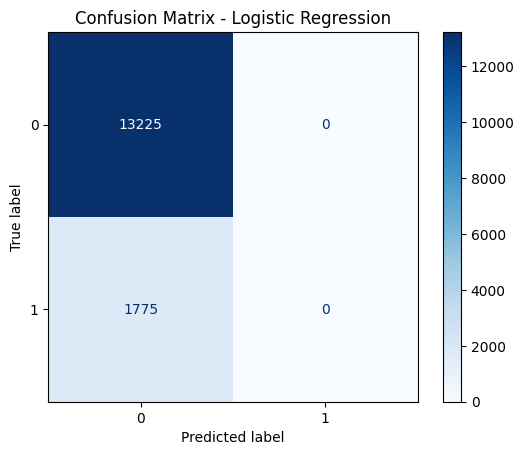

<Figure size 500x400 with 0 Axes>

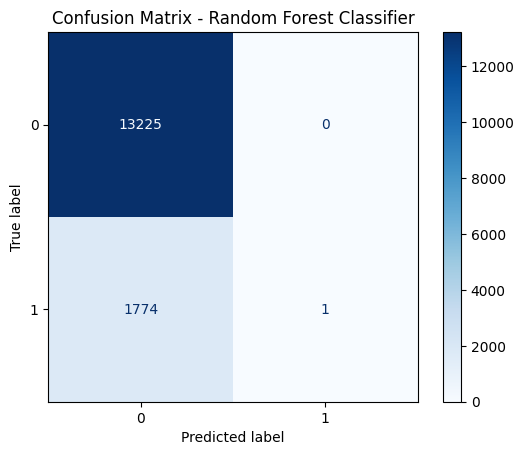

<Figure size 500x400 with 0 Axes>

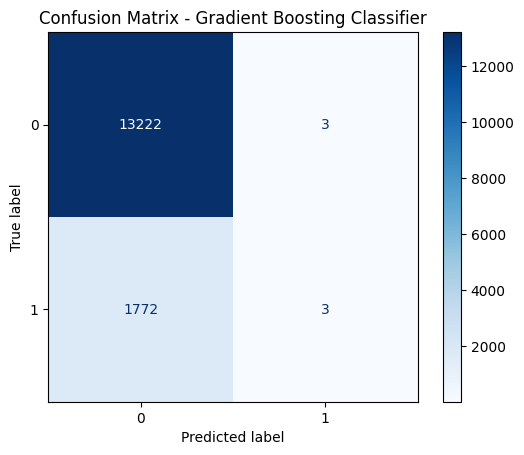

In [99]:
# Confusion Matrix Display
for model_name, model in models.items():
    plt.figure(figsize=(5, 4))

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test_final,
        y_test,
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

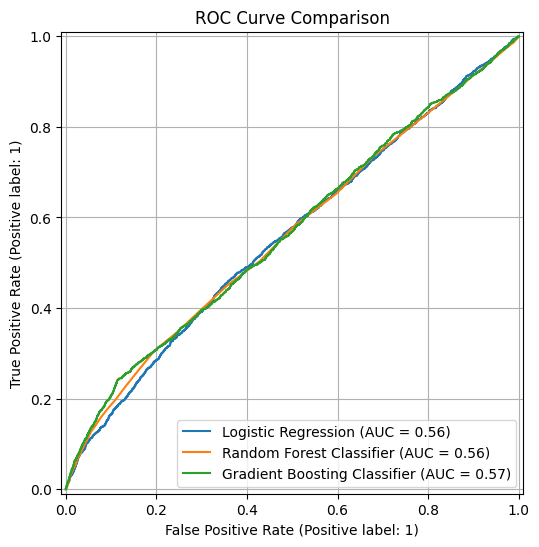

In [100]:
# ROC Curve Display
plt.figure(figsize=(8, 6))

for model_name, model in models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test_final,
        y_test,
        name=model_name,
        ax=plt.gca()
    )

plt.title("ROC Curve Comparison")
plt.grid(True)
plt.show()

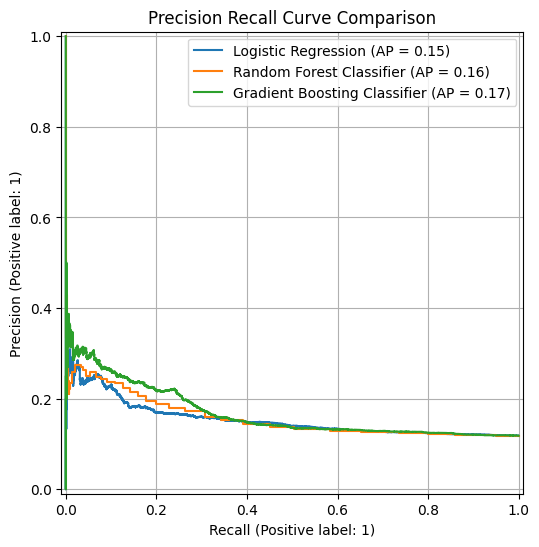

In [101]:
# Precision Recall Curve
plt.figure(figsize=(8, 6))

for model_name, model in models.items():

    PrecisionRecallDisplay.from_estimator(
        model,
        X_test_final,
        y_test,
        name=model_name,
        ax=plt.gca()
    )

plt.title("Precision Recall Curve Comparison")
plt.legend(loc=1)
plt.grid(True)
plt.show()

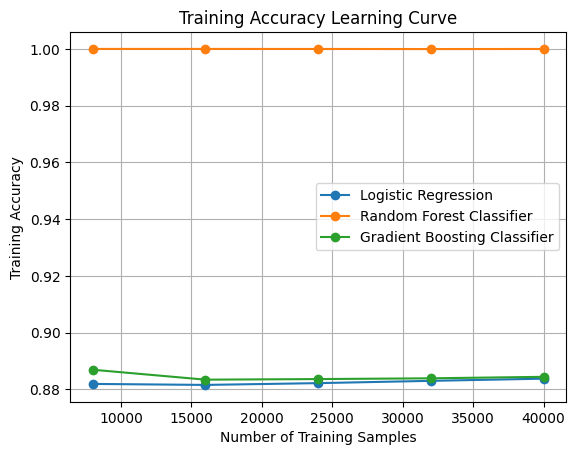

In [102]:
for model_name, model in models.items():

    train_sizes, train_scores, test_scores = learning_curve(
        estimator=model,
        X=X_train_final,
        y=y_train,
        cv=3,
        scoring="accuracy",
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)

    plt.plot(
        train_sizes,
        train_mean,
        marker="o",
        label=model_name
    )

plt.title("Training Accuracy Learning Curve")
plt.xlabel("Number of Training Samples")
plt.ylabel("Training Accuracy")
plt.legend()
plt.grid(True)

plt.show()

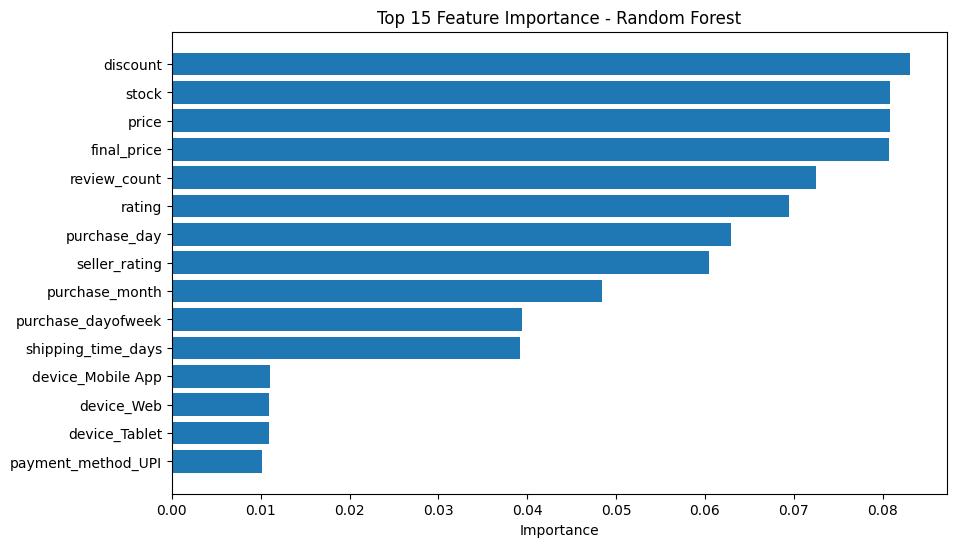

In [103]:
# Randon Forest Feature Importance
rf = models["Random Forest Classifier"]

feature_importance = pd.DataFrame({
    "Feature": all_features,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
)

plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

## Hypertuning Parameter

In [104]:
# tuned results comparison
tuned_results = []

In [105]:
# Logistic Regression Regularization

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2']
}

grid_lr = GridSearchCV(
    estimator=LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train_final, y_train)

best_lr_model = grid_lr.best_estimator_

y_train_pred_lr = best_lr_model.predict(X_train_final)
y_test_pred_lr = best_lr_model.predict(X_test_final)

tuned_results.append({
    "Model": "Logistic Regression (Tuned)",
    "Method": "GridSearchCV",
    "Best Params": grid_lr.best_params_,
    "Accuracy": accuracy_score(y_test, y_test_pred_lr),
    "Precision": precision_score(y_test, y_test_pred_lr),
    "Recall": recall_score(y_test, y_test_pred_lr),
    "F1-Score": f1_score(y_test, y_test_pred_lr),
    "Train Accuracy": accuracy_score(y_train, y_train_pred_lr),
    "Test Accuracy": accuracy_score(y_test, y_test_pred_lr),
    "Gap": accuracy_score(y_train, y_train_pred_lr)
           - accuracy_score(y_test, y_test_pred_lr)
})

c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [106]:
tuned_result_df = pd.DataFrame(tuned_results)

tuned_result_df

,Model,Method,Best Params,Accuracy,Precision,Recall,F1-Score,Train Accuracy,Test Accuracy,Gap
0,Logistic Regression (Tuned),GridSearchCV,"{'C': 0.01, 'penalty': 'l2'}",0.881667,0.0,0.0,0.0,0.883767,0.881667,0.0021


## Ekspor Model

In [ ]:
# saved model
import joblib

# save trained models
joblib.dump(
    models["Logistic Regression"],
    "logistic_regression_model.pkl"
)

joblib.dump(
    models["Random Forest Classifier"],
    "random_forest_classifier_model.pkl"
)

joblib.dump(
    models["Gradient Boosting Classifier"],
    "gradient_boosting_classifier_model.pkl"
)

# save preprocessing objects
joblib.dump(
    scaler,
    "numerical_scaler.pkl"
)

joblib.dump(
    encoder,
    "categorical_encoder.pkl"
)


['categorical_encoder.pkl']